In [2]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(eulerr)
quiet_library(ggpubr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [3]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [4]:
set.seed(123)

In [5]:
stims <- c("IFNa", "IFNg")
celltypes <- c("Bcell", "Monocyte", "Tcell", "NK")
subtypes <- c("CD4 Naive", "CD8 Naive", "CD4 Memory", "CD8 Memory", "Treg", "gdT", "MAIT", "Naive", "Memory", "Plasma",
              "NK CD56dim", "NK CD56hi")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [6]:
# cohort metadata
meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>% 
    filter(Group != "Control")


In [7]:
cohorts <- c("MM_Pretreatment", "BRI", "MM_BMMC_Internal", "MM_BMMC_Internal_Healthy")

In [8]:
cohorts <- c("MM_BMMC", "MM_BMMC_Internal")

In [15]:
# read in L1 scores
scores_df <- map_dfr(cohorts, function(cohort){
    print(cohort)
    
    map_dfr(celltypes, function(c){
        res <- fread(file.path(wd, "Cohort_IFN_scores", "NMF", cohort, glue("{cohort}_{c}_NMF_scores_scaled_v2.csv"))) %>% 
                    as.data.frame() 
        
        colnames(res) <- colnames(res) %>% stringr::str_extract("(?<=_).*") %>% replace_na(0) 
        
        rownames(res) <- stims
        res <- t(res) %>% as.data.frame()
        res$Cohort <- cohort
        res$celltype <- c
        res$KitID <- rownames(res)
        
        res
    
    })
})

scores_df <- scores_df %>% left_join(meta %>% select(KitID, SubjectID, Cohort, Misc), by = c("KitID", "Cohort"))

[1] "MM_BMMC"
[1] "MM_BMMC_Internal"


In [16]:
# set non-responding IFNg cell type NK scores to zero 
scores_df$IFNg[scores_df$celltype == "NK"] <- 0
scores_df$celltype <- factor(scores_df$celltype, levels = celltypes)

### 6B. IFNa/g L1 Score Scatterplots

In [18]:
# formatting and select cohorts
final_df_long <- scores_df %>% na.omit() %>%
    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), names_to = "stim", values_to = "score") 
select_df <- final_df_long %>% filter(Cohort %in% c("MM_BMMC_Internal", "MM_BMMC_Internal_Healthy")) %>% na.omit()

select_df$Cohort <- recode(select_df$Cohort,
                               "MM_BMMC_Internal" = "NDMM",
                               "MM_BMMC_Internal_Healthy" = "Healthy")

Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.247458114968651, 0.206619846002405, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0, 0.0987588865081435, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.151009969987061, 0.125901739409476, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.257663973954529, 0, 0, 0.0779485281811215, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.211663637367492, 0.0455089228649744, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.158168147343057, 0.179624321583359, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0116911897346842,

null device 
          1

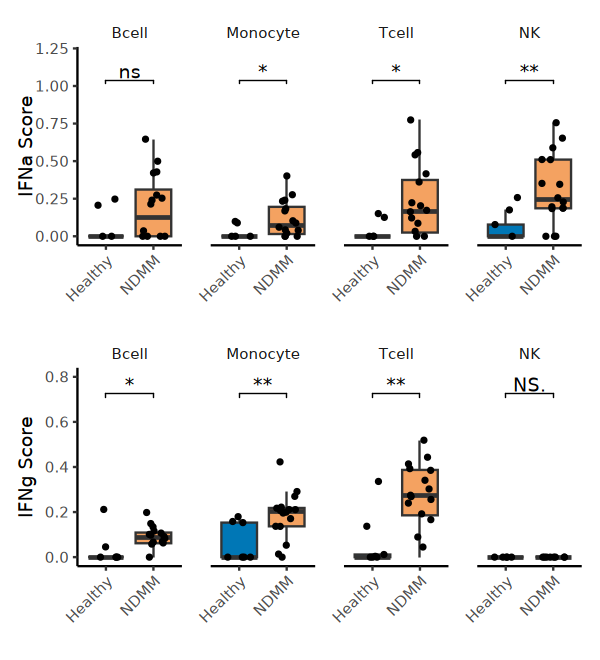

In [19]:
fig.size(5.5, 5)
#pdf(file.path(fig_dir, "Supp", "Sup6", "NDMM_Healthy_BMMC_IFNa_IFNg_Score_Boxplot.pdf"), height = 5.5, width = 5)
gg1 <- ggplot(select_df %>% filter(stim == "IFNa"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",    
      size = 4,
      label.y = 1,
      comparisons = list(c("Healthy", "NDMM"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg2 <- ggplot(select_df %>% filter(stim == "IFNg"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 0.8) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",     
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Healthy", "NDMM"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

In [23]:
# formatting and select cohorts
final_df_long <- scores_df %>% na.omit() %>%
    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), names_to = "stim", values_to = "score") 
select_df <- final_df_long %>% filter(Cohort %in% c("MM_BMMC_Internal") | Misc == "MM") %>% na.omit()



In [25]:
select_df$Cohort <- select_df$Cohort %>% recode("MM_BMMC" = "Zavidij 2020",
                                               "MM_BMMC_Internal" = "AIFI")


In [26]:
select_df$Cohort %>% table

.
        AIFI Zavidij 2020 
         128           56 

In [32]:
fig.size(5, 6)
pdf(file.path(fig_dir, "Supp", "Sup6", "NDMM_Healthy_BMMC_IFNa_IFNg_Score_Boxplot.pdf"), height = 5, width = 6)
gg1 <- ggplot(select_df %>% filter(stim == "IFNa"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    scale_fill_manual(values = c("#dde5b6", "#fcbf49")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",    
      size = 4,
      label.y = 1,
      comparisons = list(c("Zavidij 2020", "AIFI"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg2 <- ggplot(select_df %>% filter(stim == "IFNg"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    scale_fill_manual(values = c("#dde5b6", "#fcbf49")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",     
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Zavidij 2020", "AIFI"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

Warning message in wilcox.test.default(c(0.39614364266854, 0.19968476642588, 0.413097371841504, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.360837299599001, 0, 0.076768817798888, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.618728449116186, 0.180126152719989, 0.428814640379656, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.386103884448408, 0.0802045606231001, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0.0516550436194427, 0.0971082236547613, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0421243617985113, 0.0332527545256409, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.0858732258344951, 0.196747263797556, :
“cannot compute exact p-va

pdf 
  2

### 5A. Scatterplot IFN Mono vs Other Celltypes Scores 

In [20]:
final_df_select <- scores_df %>% filter(Cohort == "MM_Pretreatment")

In [21]:
mono_df <- final_df_select %>%
  filter(celltype == "Monocyte") %>%
  select(KitID, IFNa, IFNg) %>%
  rename(IFNa_Monocyte = IFNa,
        IFNg_Monocyte = IFNg)

non_mono_df <- final_df_select %>%
  filter(celltype != "Monocyte")

merged_df <- non_mono_df %>%
  left_join(mono_df, by = "KitID")

merged_df$celltype <- factor(merged_df$celltype, levels = c("Bcell", "Tcell", "NK"))

#### IFNa

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

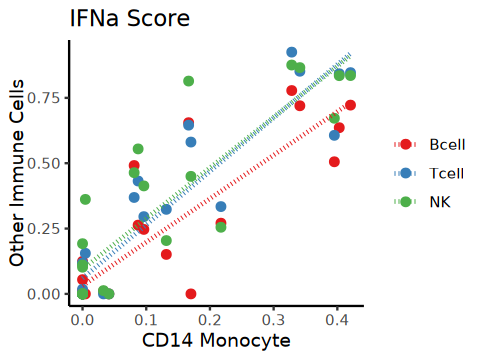

In [22]:
fig.size(3,4)
#pdf(file.path(fig_dir, "Supp", "Sup6", "NDMM_Mono_Other_Immune_Cells_IFNa_Score_Scatterplot.pdf"), height = 3, width = 4)
ggplot(merged_df, aes(x = IFNa_Monocyte, y = IFNa, color = celltype)) +
  geom_point(size = 2) +
  labs(
    x = "CD14 Monocyte",
    y = "Other Immune Cells",
    title = "IFNa Score"
  ) +
    geom_smooth(method = "lm", span = 1.5, se=F, linetype = "dotted", fullrange = F) + 
  theme_classic() +
  scale_color_brewer(palette = "Set1") +
    theme(
    legend.title = element_blank()
  )

dev.off()

In [29]:
ifna_stats <- merged_df %>%
  group_by(celltype) %>%
  summarize(
    spearman = cor(IFNa, IFNa_Monocyte, method = "pearson", use = "complete.obs"),
    p_value = cor.test(IFNa, IFNa_Monocyte, method = "pearson")$p.value,
    ifn = "IFNa"
  )

#### IFNg

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

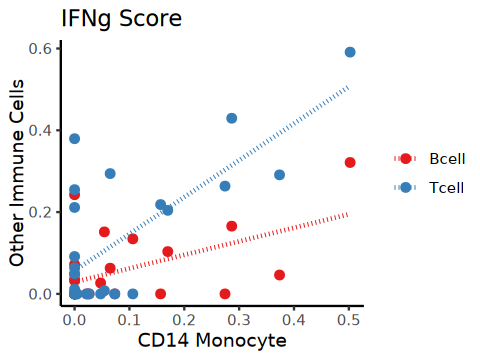

In [24]:
fig.size(3,4)
#pdf(file.path(fig_dir, "Supp", "Sup5", "NDMM_Mono_Other_Immune_Cells_IFNg_Score_Scatterplot.pdf"), height = 3, width = 4)
ggplot(merged_df %>% filter(celltype != "NK"), aes(x = IFNg_Monocyte, y = IFNg, color = celltype)) +
  geom_point(size = 2) +
  labs(
    x = "CD14 Monocyte",
    y = "Other Immune Cells",
    title = "IFNg Score"
  ) +
    geom_smooth(method = "lm", span = 1.5, se=F, linetype = "dotted", fullrange = F) + 
  theme_classic() +
  scale_color_brewer(palette = "Set1") +
    theme(
    legend.title = element_blank()
  )

dev.off()

In [30]:
ifng_stats <- merged_df %>% 
    filter(celltype != "NK") %>% 
    group_by(celltype) %>%
  summarize(
    spearman = cor(IFNg, IFNg_Monocyte, method = "spearman", use = "complete.obs"),
    p_value = cor.test(IFNg, IFNg_Monocyte, method = "spearman")$p.value,
    ifn = "IFNg"
  )

Warning message:
“There were 2 warnings in `summarize()`.
The first warning was:
ℹ In argument: `p_value = cor.test(IFNg, IFNg_Monocyte, method =
  "spearman")$p.value`.
ℹ In group 1: `celltype = Bcell`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


In [32]:
rbind(ifna_stats, ifng_stats) %>%
    fwrite(file.path(wd, "Tables", "Stats", "Sup6c_spearman_correlations.csv"))

### 5C. Scatterplots of IFNa/g score and IFNa/g protein correlations 

In [9]:
final_df <- fread(file.path(wd, "Cohort_IFN_scores", "Cohort_IFN_Scores_Assembled.csv"))

In [10]:
msd <- fread(file.path(wd, "Cohort_IFN_scores", "MSD_results_Emma.csv"), header = T) %>%
    as.data.frame()

In [11]:
cohorts <- msd$Cohort %>% unique()

In [13]:
msd <- map_dfr(cohorts, function(x){
    
    msd %>% filter(Cohort == x) %>%
      mutate(mean_IFNa_b = mean(IFNa_b[Status == "Control"])) %>%
      mutate(IFNa_log2FC = log2(IFNa_b / mean_IFNa_b)) %>%
    
      mutate(mean_IFNg = mean(IFNg[Status == "Control"])) %>%
      mutate(IFNg_log2FC = log2(IFNg / mean_IFNg)) %>%
        select(-c(IFNa, IFNb, IFNg)) 
    
    }) %>% filter(Status != "Control")
msd[msd == -Inf] <- 0
msd_final <- msd %>% left_join(final_df %>% select(KitID, IFNa, IFNg, Misc, Cohort, celltype),
                                   by = c("KitID", "Cohort")) 


In [15]:
# L1
msd_final$celltype <- factor(msd_final$celltype, levels = celltypes)

In [16]:
msd_final$Misc2 <- ifelse(msd_final$Misc %in% c("NDMM-VRd", "NDMM-DVRd"), "Pretreat", msd_final$Misc)
msd_select <- msd_final %>% filter(Misc2 %in% c("Pretreat", "VRd", "DVRd"))
msd_select$Misc2 <- factor(msd_select$Misc2, levels = c("Pretreat", "VRd", "DVRd"))

In [17]:
msd_select %>% head

,SubjectID,Cohort,Status,KitID,IFNa_b,mean_IFNa_b,IFNa_log2FC,mean_IFNg,IFNg_log2FC,IFNa,IFNg,Misc,celltype,Misc2
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<fct>
1,FH1003,MM_EndInduction,,KT00137,247.38,33.85616,2.869239,501.2148,1.918979,0.00000000,0.11438134,VRd,Bcell,VRd
2,FH1003,MM_EndInduction,,KT00137,247.38,33.85616,2.869239,501.2148,1.918979,0.09074368,0.31393119,VRd,Tcell,VRd
3,FH1003,MM_EndInduction,,KT00137,247.38,33.85616,2.869239,501.2148,1.918979,0.00000000,0.07277079,VRd,Monocyte,VRd
4,FH1003,MM_EndInduction,,KT00137,247.38,33.85616,2.869239,501.2148,1.918979,0.00000000,0.00000000,VRd,NK,VRd
5,FH1004,MM_EndInduction,,KT00138,311.08,33.85616,3.199795,501.2148,1.823895,0.00000000,0.00000000,VRd,Bcell,VRd
6,FH1004,MM_EndInduction,,KT00138,311.08,33.85616,3.199795,501.2148,1.823895,0.00000000,0.00000000,VRd,Tcell,VRd


#### IFNa

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

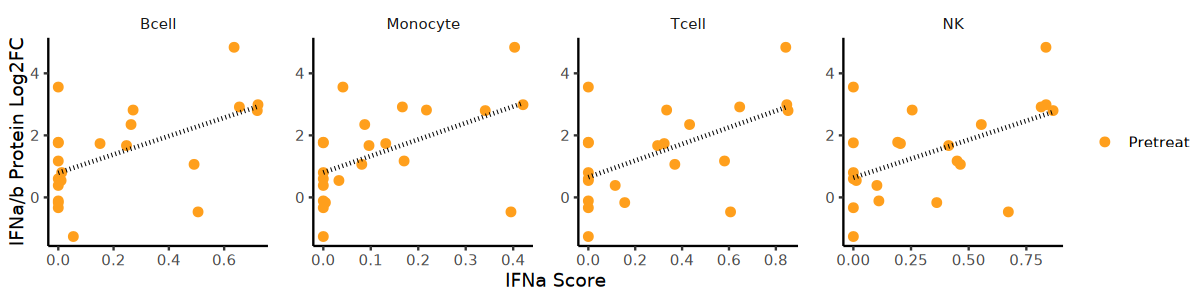

In [25]:
fig.size(2.5,10)
#pdf(file.path(fig_dir, "Supp", "Sup5", "MM_Pretreat_VRd_DVRd_IFNa_Score_Protein_Correlation_Scatterplots_L1.pdf"), height = 2.5, width = 10)
ggplot(msd_select %>% filter(Misc2 == "Pretreat"), aes(x = IFNa, y = IFNa_log2FC, color = Misc2)) +
  geom_point(size = 2) + 
  facet_wrap(~celltype, ncol = 4, scales = "free") + 
  theme_classic() +
  labs(x = "IFNa Score", y = "IFNa/b Protein Log2FC") + 
  geom_smooth(method = "lm", span =1.5, se = F,  linetype = "dotted", fullrange = F, color = "black") + 
    scale_color_manual(values = c("#ff9f1c")) +
  #geom_text(data = label_positions,
  #          aes(x = x, y = y, label = paste("r =", round(correlation, 2),
  #                                          "\nP = ", signif(pval, 2))),
  #          hjust = 0, vjust = 1, size = 4, show.legend = FALSE, color = "black") +
theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank())
dev.off()

In [37]:
correlations1 <- msd_final %>% filter(Misc2 %in% c("Pretreat", "VRd", "DVRd")) %>% na.omit() %>%
  group_by(celltype, Misc2) %>%
  summarize(correlation = cor.test(IFNa, IFNa_log2FC, method = "spearman")$estimate,
           pval = cor.test(IFNa, IFNa_log2FC, method = "spearman")$p.val)

Warning message:
“There were 22 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNa, IFNa_log2FC, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = Bcell` `Misc2 = "DVRd"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 21 remaining warnings.”
`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


In [42]:
correlations1 %>% fwrite(file.path(wd, "IFNa_Score_IFNa_Protein_Correlation_Stats.csv"))

#### IFNg

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

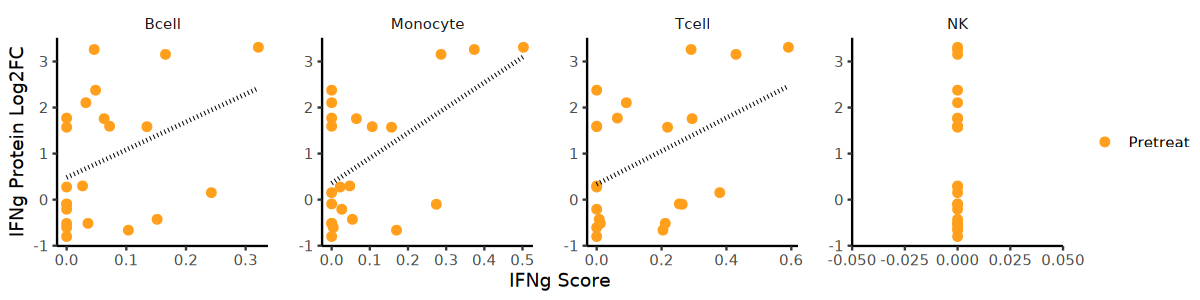

In [26]:
fig.size(2.5,10)
#pdf(file.path(fig_dir, "Supp", "Sup5", "MM_Pretreat_VRd_DVRd_IFNg_Score_Protein_Correlation_Scatterplots_L1.pdf"), height = 2.5, width = 10)
ggplot(msd_select %>% filter(Misc2 == "Pretreat"), aes(x = IFNg, y = IFNg_log2FC, color = Misc2)) +
  geom_point(size = 2) + 
  facet_wrap(~celltype, ncol = 4, scales = "free") + 
  theme_classic() +
  labs(x = "IFNg Score", y = "IFNg Protein Log2FC") + 
  geom_smooth(method = "lm", span =1.5, se = F,  linetype = "dotted", fullrange = F, color = "black") + 
    scale_color_manual(values = c("#ff9f1c")) +
  #geom_text(data = label_positions,
  #          aes(x = x, y = y, label = paste("r =", round(correlation, 2),
  #                                          "\nP = ", signif(pval, 2))),
  #          hjust = 0, vjust = 1, size = 4, show.legend = FALSE, color = "black") +
theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank())
dev.off()

In [56]:
correlations2 <- msd_final %>% filter(Misc2 %in% c("Pretreat", "VRd", "DVRd")) %>% na.omit() %>%
  group_by(celltype, Misc2) %>%
  summarize(correlation = cor.test(IFNg, IFNg_log2FC, method = "spearman")$estimate,
           pval = cor.test(IFNg, IFNg_log2FC, method = "spearman")$p.val)


Warning message:
“There were 24 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNg, IFNg_log2FC, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = Bcell` `Misc2 = "DVRd"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 23 remaining warnings.”
`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


In [ ]:
correlations2 %>% fwrite(file.path(wd, "IFNg_Score_IFNg_Protein_Correlation_Stats.csv"))

### 5D. MM Pretreatment IFNa/g Score Scatterplots

In [22]:
select_df <- final_df %>% filter(Misc %in% c("NDMM-VRd", "NDMM-DVRd", "VRd", "DVRd"))

In [23]:
select_df$Misc2 <- ifelse(select_df$Misc %in% c("NDMM-VRd", "NDMM-DVRd"), "Pretreat", select_df$Misc)
select_df$Misc2 <- factor(select_df$Misc2, levels = c("Pretreat", "VRd", "DVRd"))

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

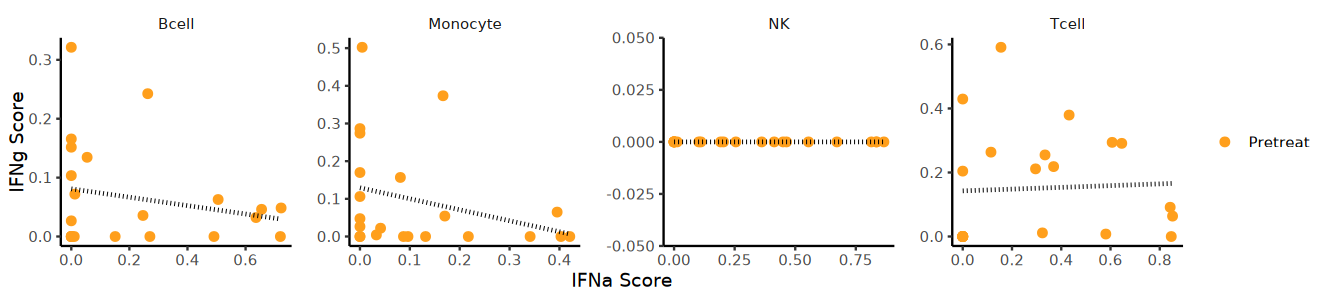

In [27]:
fig.size(2.5,11)

#pdf(file.path(fig_dir, "Supp", "Sup5", "Pretreat_VRd_DVRd_IFNa_IFNg_Scatterplots.pdf"), height = 2.5, width = 11)
ggplot(select_df %>% filter(Misc2 == "Pretreat"), aes(x=IFNa, y=IFNg, color = Misc2)) +
    #xlim(0,0.9) + ylim(0,0.9) + 
    geom_point(size = 2) + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    theme_classic() + 
    #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray") + 
    scale_size(range = c(3,8), guide = "none") + 
    scale_color_manual(values = c("#ff9f1c", "#4895ef", "#8ac926")) +
    
    geom_smooth(method = "lm", span = 1.5, se=F, linetype = "dotted", fullrange = F, color = "black") + 
    theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank()
      ) + 
    labs(x = "IFNa Score", y = "IFNg Score")
dev.off()

In [40]:
correlations <- select_df %>%
  group_by(celltype, Misc2) %>%
  summarize(correlation = cor.test(IFNa, IFNg, method = "spearman")$estimate,
           pval = cor.test(IFNa, IFNg, method = "spearman")$p.val)

Warning message:
“There were 24 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNa, IFNg, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = "Bcell"` `Misc2 = "DVRd"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 23 remaining warnings.”
`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


In [42]:
correlations %>% 
    fwrite(file.path(wd, "Tables", "Stats", "Fig5_Pretreat_VRd_DVRd_IFNa_IFNg_Spearman_Scatterplot.csv"))

### 5E. Scatterplots of IFNa and MM DEGs logfc values

In [76]:
# pull in MM PBMC sample KitIDs
ids <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>%
    filter(Group == "MM_Pretreatment") %>% pull(KitID) %>% unique()

l1_degs <- fread(file.path(wd, "DEGs", "L1_All_Celltypes_Stims_N1_DEGs.csv")) %>%
            filter(Significant == "Yes")

stim_select <- "IFNa"

In [77]:
df <- map_dfr(celltypes, function(c){
    
        stim_degs <- l1_degs %>% filter(stim == stim_select & celltype == c) %>%
                mutate(stim_log2FC = median_log2FC)
    #print(table(stim_degs$stim))
    
        degs_celltype <- map_dfr(ids, function(i){
            
            degs <- fread(file.path(wd, "Cohort_IFN_scores", "Cohort_DEGs", "MM_Pretreatment", glue("{c}_{i}_MAST_degs.csv"))) 
            
            degs <- degs %>% 
                filter(pct.1 > 0.01 & pct.2 > 0.01) %>%
                select(avg_log2FC, gene) %>% 
                filter(gene %in% stim_degs$gene)
            
                  
            degs$celltype <- c
            degs$id <- i
            degs
        })
    
    degs_celltype %>% 
        group_by(gene) %>%
        summarise(MM_log2FC = mean(avg_log2FC)) %>%
        left_join(stim_degs, by = "gene")
    })

In [73]:
df %>%
    group_by(celltype) %>% 
  mutate(
    rank_stim = rank(-stim_log2FC),
    rank_MM = rank(-MM_log2FC),
    combined_rank = rank_stim + rank_MM
  ) %>%
  arrange(celltype, combined_rank) %>%
    select(gene, stim_log2FC, MM_log2FC)  %>% 
    fwrite(file.path(wd, "Tables", glue("{stim_select}_ISGs_MM_Stim_Log2FC_Scatterplot_Values.csv")))

Adding missing grouping variables: `celltype`


In [80]:
mm_genes_df <- fread(file.path(wd, "Tables", glue("{stim_select}_MM_L1_ISGs.csv")))

[1] "Bcell"    "Monocyte" "Tcell"    "NK"

In [85]:
ggs <- lapply(celltypes, function(c){
    print(c)
    mm_genes <- mm_genes_df %>% pull(c)
    genes_label_mm <- fread(file.path(wd, "Tables", glue("{stim_select}_ISGs_MM_Stim_Log2FC_Scatterplot_Values.csv"))) %>%
        filter(celltype == c) %>% pull(gene) %>% intersect(mm_genes) %>% .[1:3]
    
    celltype_df <- df %>% 
        filter(celltype == c)%>%
        mutate(
          color = case_when(
            gene %in% genes_label_mm ~ "darkred",
            stim_log2FC > 0 & MM_log2FC > 0 ~ "red",  
            stim_log2FC < 0 & MM_log2FC < 0 ~ "blue", 
            TRUE ~ "gray"                      # All other cases
          )
        )
    genes_label <- c(celltype_df %>% filter(color == "red") %>% slice_max(stim_log2FC, n = 5) %>% pull(gene),
                     celltype_df %>% filter(color == "red") %>% slice_max(MM_log2FC, n = 5) %>% pull(gene),
                    celltype_df %>% filter(color == "blue") %>% slice_min(stim_log2FC, n = 5) %>% pull(gene),
                     celltype_df %>% filter(color == "blue") %>% slice_min(MM_log2FC, n = 5) %>% pull(gene))
   
         
    celltype_df$label <- ifelse(celltype_df$gene %in% c(genes_label, genes_label_mm), celltype_df$gene, NA)

    ggplot(celltype_df, aes(x=stim_log2FC, y=MM_log2FC, label = label, color = color)) +
      geom_point(alpha = 1) + 
        ggrepel::geom_text_repel(max.overlaps = 100) + 
        theme_minimal() + 
         #lims(x = c(-3,5),
         #    y = c(-1,1.5)) + 
        lims(x = c(-6.7,4.6),
             y = c(-1,1.5)) + 
      geom_hline(yintercept = 0, linetype = "solid", linewidth = 0.5) +
      geom_vline(xintercept = 0, linetype = "solid", linewidth = 0.5) +
        scale_color_manual(values=c('blue' = 'blue','gray' = 'gray','red' = 'red', 'darkred' = '#780000')) + 
        ggtitle(c) + 
        theme(legend.position = "none",
             plot.title = element_text(hjust = 0.5, face = "bold"),
             panel.grid = element_blank()) + 
        labs(x = "Stim Log2FC", y = "MM Log2FC")
    })

[1] "Bcell"
[1] "Monocyte"
[1] "Tcell"
[1] "NK"


Warning message:
“Removed 256 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 273 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 128 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 180 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


null device 
          1

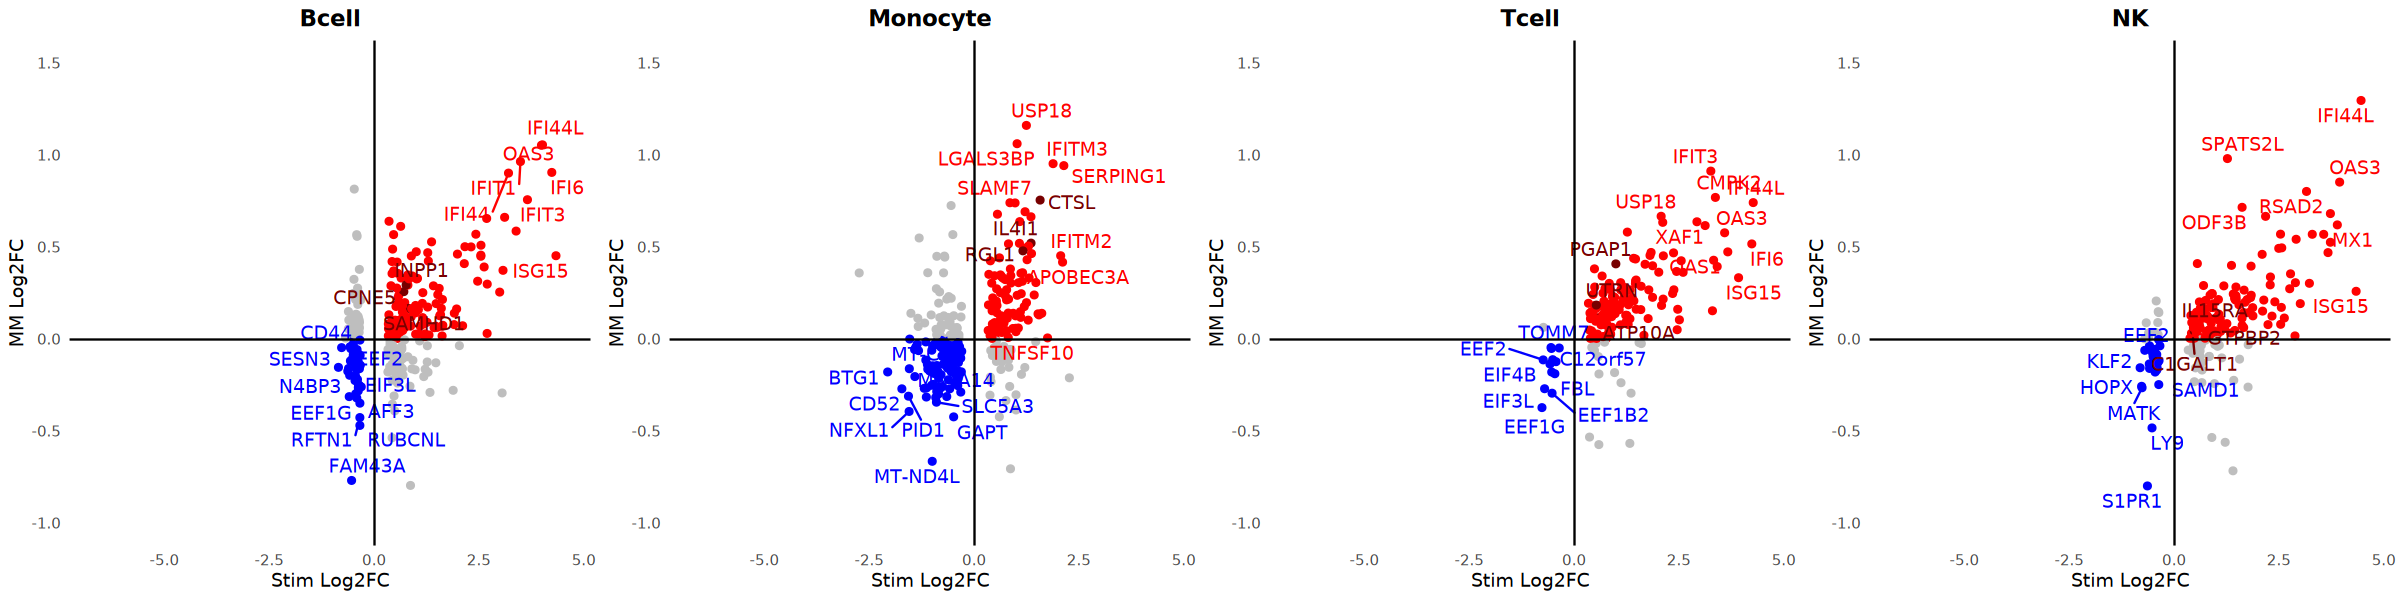

In [88]:
fig.size(5,20)
#pdf(file.path(wd, "Figures", "Supp", "Sup6", glue("{stim}_Stim_MM_ISGs_Log2FC_Scatterplots.pdf")), 
#    height = 5, width = 15)
grid.arrange(grobs = ggs, ncol = 4)
dev.off()

### 5F. Scatterplots of IFNa and MM DEGs logfc values

In [52]:
stim_select <- "IFNg"

In [62]:
df <- map_dfr(celltypes, function(c){
    
        stim_degs <- l1_degs %>% filter(stim == stim_select & celltype == c) %>%
                mutate(stim_log2FC = median_log2FC)
    #print(table(stim_degs$stim))
    
        degs_celltype <- map_dfr(ids, function(i){
            
            degs <- fread(file.path(wd, "Cohort_IFN_scores", "Cohort_DEGs", "MM_Pretreatment", glue("{c}_{i}_MAST_degs.csv"))) 
            
            degs <- degs %>% 
                filter(pct.1 > 0.01 & pct.2 > 0.01) %>%
                select(avg_log2FC, gene) %>% 
                filter(gene %in% stim_degs$gene)
            
                  
            degs$celltype <- c
            degs$id <- i
            degs
        })
    
    degs_celltype %>% 
        group_by(gene) %>%
        summarise(MM_log2FC = mean(avg_log2FC)) %>%
        left_join(stim_degs, by = "gene")
    })

In [63]:
df %>%
    group_by(celltype) %>% 
  mutate(
    rank_stim = rank(-stim_log2FC),
    rank_MM = rank(-MM_log2FC),
    combined_rank = rank_stim + rank_MM
  ) %>%
  arrange(celltype, combined_rank) %>%
    select(gene, stim_log2FC, MM_log2FC)  %>% 
    fwrite(file.path(wd, "Tables", glue("{stim_select}_ISGs_MM_Stim_Log2FC_Scatterplot_Values.csv")))

Adding missing grouping variables: `celltype`


In [64]:
mm_genes_df <- fread(file.path(wd, "Tables", glue("{stim_select}_MM_L1_ISGs.csv")))

In [65]:
ggs <- lapply(celltypes[1:3], function(c){
    mm_genes <- mm_genes_df %>% pull(c)
    genes_label_mm <- fread(file.path(wd, "Tables", glue("{stim_select}_ISGs_MM_Stim_Log2FC_Scatterplot_Values.csv"))) %>%
        filter(celltype == c) %>% pull(gene) %>% intersect(mm_genes) %>% .[1:3]
    
    celltype_df <- df %>% 
        filter(celltype == c)%>%
        mutate(
          color = case_when(
            gene %in% genes_label_mm ~ "darkred",
            stim_log2FC > 0 & MM_log2FC > 0 ~ "red",  
            stim_log2FC < 0 & MM_log2FC < 0 ~ "blue", 
            TRUE ~ "gray"                      # All other cases
          )
        )
    genes_label <- c(celltype_df %>% filter(color == "red") %>% slice_max(stim_log2FC, n = 5) %>% pull(gene),
                     celltype_df %>% filter(color == "red") %>% slice_max(MM_log2FC, n = 5) %>% pull(gene),
                    celltype_df %>% filter(color == "blue") %>% slice_min(stim_log2FC, n = 5) %>% pull(gene),
                     celltype_df %>% filter(color == "blue") %>% slice_min(MM_log2FC, n = 5) %>% pull(gene))
   
         
    celltype_df$label <- ifelse(celltype_df$gene %in% c(genes_label, genes_label_mm), celltype_df$gene, NA)

    ggplot(celltype_df, aes(x=stim_log2FC, y=MM_log2FC, label = label, color = color)) +
      geom_point(alpha = 1) + 
        ggrepel::geom_text_repel(max.overlaps = 100) + 
        theme_minimal() + 
         #lims(x = c(-3,5),
         #    y = c(-1,1.5)) + 
        lims(x = c(-6.7,4.6),
             y = c(-1,1.5)) + 
      geom_hline(yintercept = 0, linetype = "solid", linewidth = 0.5) +
      geom_vline(xintercept = 0, linetype = "solid", linewidth = 0.5) +
        scale_color_manual(values=c('blue' = 'blue','gray' = 'gray','red' = 'red', 'darkred' = '#780000')) + 
        ggtitle(c) + 
        theme(legend.position = "none",
             plot.title = element_text(hjust = 0.5, face = "bold"),
             panel.grid = element_blank()) + 
        labs(x = "Stim Log2FC", y = "MM Log2FC")
    })

Warning message:
“Removed 173 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 608 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 32 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


null device 
          1

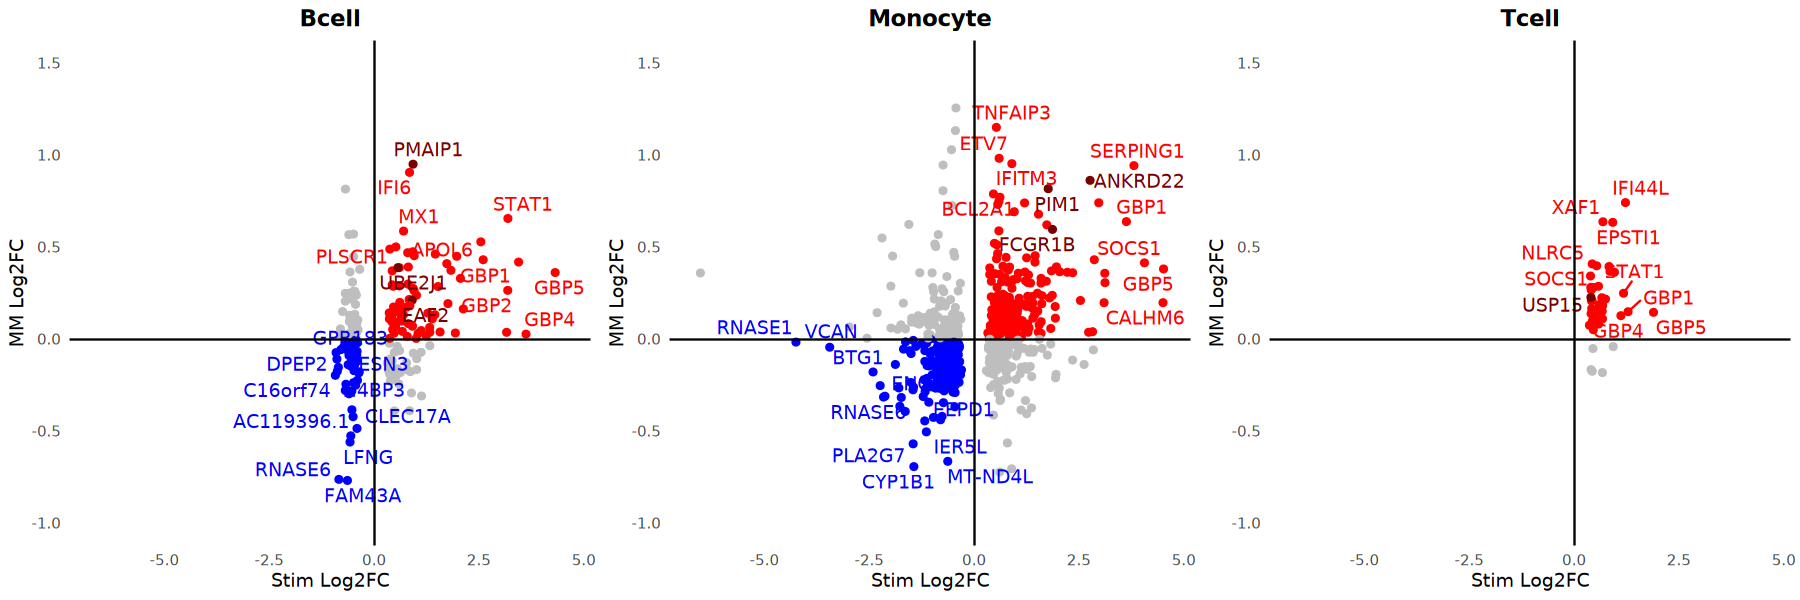

In [66]:
fig.size(5,15)
#pdf(file.path(wd, "Figures", "Supp", "Sup6", glue("{stim}_Stim_MM_ISGs_Log2FC_Scatterplots.pdf")), 
#    height = 5, width = 15)
grid.arrange(grobs = ggs, ncol = 3)
dev.off()

### 5G. L1 NDMM vs Induction PBMC Cell Percentage Box Plots

In [28]:
vars <-  c("BRI", "NDMM-VRd", "VRd", "NDMM-DVRd", "DVRd")
cohort_meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>%
    filter(Group != "Control" & !(Group %in% c("BRI_aging_M", "BRI_aging_F")) & 
          Misc %in% vars)

In [29]:
so1 <- readRDS(file.path(wd, "Cohort_IFN_scores", "Seurat_objects", "MM_Pretreatment_so.rds"))
so2 <- readRDS(file.path(wd, "Cohort_IFN_scores", "Seurat_objects", "MM_EndInduction_so.rds")) 

In [30]:
meta <- so1@meta.data %>%
            filter(KitID %in% cohort_meta$KitID) %>%
            left_join(cohort_meta %>% select(KitID, Group, Cohort, Misc),
             by = "KitID") %>% filter(Misc != "BRI") %>%
    rbind(so2@meta.data %>%
            filter(KitID %in% cohort_meta$KitID) %>%
            left_join(cohort_meta %>% select(KitID, Group, Cohort, Misc),
             by = "KitID") %>% filter(Misc != "BRI")
            ) %>%
    mutate(Misc2 = ifelse(Misc %in% c("NDMM-VRd", "NDMM-DVRd"), "NDMM", Misc))

In [31]:
meta2 <- so1@meta.data %>%
            filter(KitID %in% cohort_meta$KitID) %>%
            left_join(cohort_meta %>% select(KitID, Group, Cohort, Misc),
             by = "KitID") %>% 
    mutate(Misc2 = ifelse(Misc %in% c("NDMM-VRd", "NDMM-DVRd"), "NDMM", Misc))

In [32]:
# generate cell type frequency table
freq_table <- meta %>%
  group_by(KitID, celltype.l1) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(KitID) %>%
  mutate(freq = 100 * n / sum(n)) %>%
  left_join(meta %>% select(KitID, Cohort, Misc) %>% distinct(), by = "KitID") %>%
    filter(celltype.l1 %in% celltypes) %>%
    na.omit() %>%
    mutate(Misc = factor(Misc, levels = vars))

In [33]:
comparisons <- list(
  c("NDMM-VRd", "VRd"),
  c("NDMM-DVRd", "DVRd")
    )


In [17]:
freq_table %>% fwrite(file.path(wd, "Tables", "Fig7_L1_PBMC_Freq_Boxplots_CellN_Frequencies.csv"))

null device 
          1

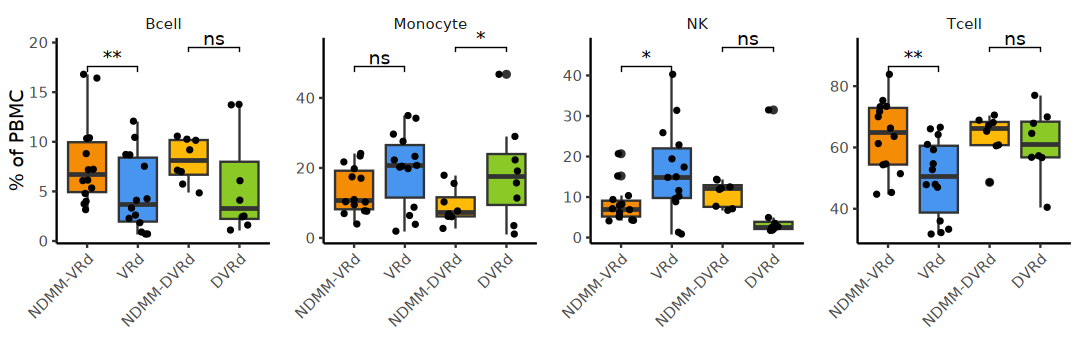

In [14]:
fig.size(3,9)
#pdf(file.path(wd, "Figures", "Supp", "Sup5", "L1_PBMC_NDMM_VRd_Freq_Boxplots.pdf"), height = 3, width = 9)
ggplot(freq_table, aes(x = Misc, y = freq, fill = Misc)) +
  geom_boxplot() +
    geom_jitter(width = 0.25, size = 1) + 
  stat_compare_means(
    comparisons = comparisons,
    method = "wilcox.test",
    paired = T,
    label = "p.signif"
  ) +
    facet_wrap(~celltype.l1, ncol = 4, scales = "free") + 
    theme_classic() +
    scale_fill_manual(values = c("#f48c06", "#4895ef", "#ffba08", "#8ac926")) + 
    ylab("% of PBMC") +
    xlab("") +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines")) + 
    coord_cartesian(clip = "off")
dev.off()


In [15]:
# save stats
results <- freq_table %>%
  group_by(celltype.l1) %>%
  group_split() %>%
  map_dfr(function(group_df) {
    map_dfr(comparisons, function(pair) {
      sub_df <- group_df %>% filter(Misc %in% pair)
      if (length(unique(sub_df$Misc)) == 2) {
        means <- sub_df %>% group_by(Misc) %>% summarise(mean_score = mean(freq), .groups = "drop")
        diff <- means$mean_score[means$Misc == pair[1]] - means$mean_score[means$Misc == pair[2]]
        test <- wilcox.test(freq ~ Misc, data = sub_df, paired = T)
        tibble(
          celltype = unique(group_df$celltype.l1),
          group1 = pair[1],
          group2 = pair[2],
          mean_percent_diff = diff,
          p_value = test$p.value
        )
      } 
    })
  }) %>% as.data.frame()


In [ ]:
results %>% fwrite(file.path(wd, "Tables", "L1_PBMC_Freq_Boxplots_Wilcox.csv"))